# HI MASS PER GAXALY OF THE SYSTEM ARP86

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS

In [42]:
# observational data
data_cube = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/S2349+2904_HIcube2_clean_smooth_image_5_cube_kms.fits")
data_header =fits.getheader("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/S2349+2904_HIcube2_clean_smooth_image_5_cube_kms.fits")
# mask 
data_mask= fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/S2349+2904_HIcube2_clean_smooth_image_5_mask_kms.fits")


# modeling data 
#data models
directory_7753 = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/"
data_model_ngc7753 = fits.getdata(directory_7753 + "output3/SoFiA_J234703.61+292835.6/SoFiA_J234703.61+292835.6mod_azim.fits")
#
directory_7752 = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7752/"
data_model_ngc7752 = fits.getdata(directory_7752 + "output/SoFiA_J234703.61+292835.6/SoFiA_J234703.61+292835.6mod_azim.fits")
#
directory_companion = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/USNOA2-1125-19940303/"
data_model_companion = fits.getdata(directory_companion+"output/SoFiA_J234703.61+292835.6/SoFiA_J234703.61+292835.6mod_azim.fits")


In [43]:
# apply the mask 
masked_data = np.where(data_mask, data_cube, 0)

In [44]:
# fucntion to calculate the HI mass of the galaxy
def computeHImass(masked_data, data_header):
    Npix_beam = (1.133*data_header['BMAJ']*data_header['BMIN'])/(abs(data_header['CDELT1'])*abs(data_header['CDELT2'])) # number of pixels per beam
    S_int_value = (np.nansum(masked_data)*abs(data_header['CDELT3'])*1e-3)/Npix_beam # Jy km/s
    D = 66.63 #Nasa extragalactic database
    M_HI = 2.356e5 * D**2 * S_int_value # solar masses
    return M_HI

In [27]:
Npix_beam = (1.133*data_header['BMAJ']*data_header['BMIN'])/(abs(data_header['CDELT1'])*abs(data_header['CDELT2'])) # number of pixels per beam
S_int_value = (np.nansum(masked_data)*abs(data_header['CDELT3'])*1e-3)/Npix_beam # Jy km/s

In [28]:
# totla HI mass
D = 66.63 #Nasa extragalactic database
M_HI = 2.356e5 * D**2 * S_int_value # solar masses
print(f"HI Mass: {format(M_HI,".2e")} solar masses") 

HI Mass: 2.11e+10 solar masses


## HI mass of each galaxy

In [45]:
data_ngc7753 = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/ngc7753_cube1.fits")
header_ngc7753 = fits.getheader("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/ngc7753_cube1.fits")    

In [46]:
HImassNgc7753=computeHImass(data_ngc7753, header_ngc7753)
print(f"Observational HI Mass of NGC7753: {format(HImassNgc7753,".2e")} solar masses")
# model 
HImassModelNgc7753=computeHImass(data_model_ngc7753, header_ngc7753)
print(f"Model HI Mass of NGC7753: {format(HImassModelNgc7753,".2e")} solar masses")

Observational HI Mass of NGC7753: 1.07e+10 solar masses
Model HI Mass of NGC7753: 1.19e+10 solar masses


In [47]:
data_ngc7752   = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7752/ngc7752_cube1.fits")
header_ngc7752 = fits.getheader("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7752/ngc7752_cube1.fits")


In [48]:
HImassNgc7752=computeHImass(data_ngc7752, header_ngc7752)
print(f"HI Mass of NGC7752: {format(HImassNgc7752,".2e")} solar masses")

# model
HImassModelNgc7752=computeHImass(data_model_ngc7752, header_ngc7752)
print(f"Model HI Mass of NGC7752: {format(HImassModelNgc7752,".2e")} solar masses")

HI Mass of NGC7752: 2.69e+09 solar masses
Model HI Mass of NGC7752: 1.81e+09 solar masses


In [49]:
data_USNOA   = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/USNOA2-1125-19940303/arp86-3_cube1.fits")
header_USNOA = fits.getheader("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/USNOA2-1125-19940303/arp86-3_cube1.fits")


In [50]:
HImassUSNOA=computeHImass(data_USNOA, header_USNOA)
print(f"HI Mass of USNOA2-1125-19940303: {format(HImassUSNOA,".2e")} solar masses") 

#model
HImassModelUSNOA=computeHImass(data_model_companion, header_USNOA)
print(f"Model HI Mass of USNOA2-1125-19940303: {format(HImassModelUSNOA,".2e")} solar masses")

HI Mass of USNOA2-1125-19940303: 4.06e+09 solar masses
Model HI Mass of USNOA2-1125-19940303: 6.59e+08 solar masses


## HI Mass of residuals

In [35]:
# data of the model NGC7753
directory_7753 = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/"
data_model_ngc7753 = fits.getdata(directory_7753 + "output3/SoFiA_J234703.61+292835.6/SoFiA_J234703.61+292835.6mod_azim.fits")

# data for the model ngc7752
directory_7752 = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7752/"
data_model_ngc7752 = fits.getdata(directory_7752 + "output/SoFiA_J234703.61+292835.6/SoFiA_J234703.61+292835.6mod_azim.fits")
data_ngc7752 = fits.getdata(directory_7752 + "ngc7752_cube1.fits")

# data for the model of the companion galaxy 2MASXJ23470758+2926531
directory_companion = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/USNOA2-1125-19940303/"
data_model_companion = fits.getdata(directory_companion+"output/SoFiA_J234703.61+292835.6/SoFiA_J234703.61+292835.6mod_azim.fits")
data_arp3 = fits.getdata(directory_companion + "arp86-3_cube1.fits")


In [51]:
residuals= (data_cube - data_model_ngc7753-data_model_ngc7752-data_model_companion)
data_res_masked = np.where(data_mask, residuals, 0)
data_res_masked = np.where(data_res_masked<0,0,data_res_masked)

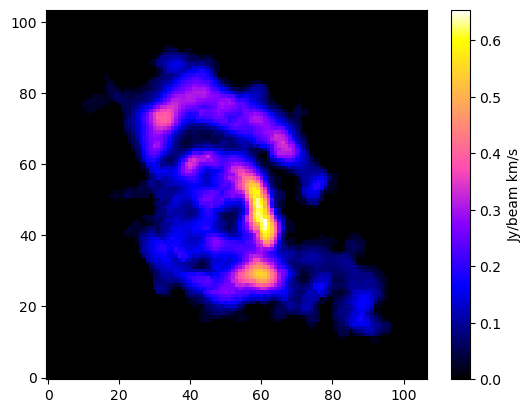

In [38]:
mom0_residual = np.nansum(data_res_masked, axis=0) * abs(data_header['CDELT3']) * 1e-3 # Jy/beam km/s
#mom0_residual = np.where(mom0_residual < 0, 0, mom0_residual)
plt.imshow(mom0_residual, origin='lower', cmap='gnuplot2')
plt.colorbar(label='Jy/beam km/s')

In [52]:
HImassResidual=computeHImass(data_res_masked, data_header)
print(f"HI Mass of the residual: {format(HImassResidual,".2e")} solar masses")

HI Mass of the residual: 1.19e+10 solar masses


## Summary table of HI masses

In [ ]:
import pandas as pd

galaxy_rows = [
    ("NGC7753", HImassNgc7753, HImassModelNgc7753, HImassNgc7753 - HImassModelNgc7753),
    ("NGC7752", HImassNgc7752, HImassModelNgc7752, HImassNgc7752 - HImassModelNgc7752),
    ("USNOA2-1125-19940303", HImassUSNOA, HImassModelUSNOA, HImassUSNOA - HImassModelUSNOA),
]

total_observational = HImassNgc7753 + HImassNgc7752 + HImassUSNOA
total_model = HImassModelNgc7753 + HImassModelNgc7752 + HImassModelUSNOA

summary_rows = galaxy_rows + [
    ("System total", total_observational, total_model, HImassResidual),
]

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Galaxy", "Observational [Msun]", "Model [Msun]", "Residual [Msun]"],
)

formatted_summary_df = summary_df.copy()
for column in ["Observational [Msun]", "Model [Msun]", "Residual [Msun]"]:
    formatted_summary_df[column] = formatted_summary_df[column].map(lambda value: f"{value:.2e}")

display(formatted_summary_df)
print("Galaxy residuals are computed as observational - model.")
print("The 'System total' residual comes from the residual cube mass.")

| Galaxy | Observational [$M_\odot$] | Model [$M_\odot$] | Residual [$M_\odot$] |
|---|---:|---:|---:|
| NGC7753 | 1.07e+10 | 1.19e+10 | -1.19e+09 |
| NGC7752 | 2.69e+09 | 1.81e+09 | 8.83e+08 |
| USNOA2-1125-19940303 | 4.06e+09 | 6.59e+08 | 3.40e+09 |
| System total | 1.75e+10 | 1.44e+10 | 1.19e+10 |

Galaxy residuals are computed as observational - model.
The 'System total' residual comes from the residual cube mass.


## Summary table in log10 scale

In [ ]:
def format_log_mass(value):
    if value > 0:
        return f"{np.log10(value):.2f}"
    return "--"

def format_residual_sign(value):
    if value > 0:
        return "+"
    if value < 0:
        return "-"
    return "0"

log_summary_df = pd.DataFrame(
    {
        "Galaxy": [row[0] for row in summary_rows],
        "log10(Observational / Msun)": [format_log_mass(row[1]) for row in summary_rows],
        "log10(Model / Msun)": [format_log_mass(row[2]) for row in summary_rows],
        "Residual sign": [format_residual_sign(row[3]) for row in summary_rows],
        "log10(|Residual| / Msun)": [format_log_mass(abs(row[3])) for row in summary_rows],
    }
)

display(log_summary_df)
print("Residuals are shown with separate sign and logarithmic absolute value.")

| Galaxy | log10(Observational / $M_\odot$) | log10(Model / $M_\odot$) | Residual sign | log10(|Residual| / $M_\odot$) |
|---|---:|---:|:---:|---:|
| NGC7753 | 10.03 | 10.08 | - | 9.08 |
| NGC7752 | 9.43 | 9.26 | + | 8.95 |
| USNOA2-1125-19940303 | 9.61 | 8.82 | + | 9.53 |
| System total | 10.24 | 10.16 | + | 10.08 |

Residuals are shown with separate sign and logarithmic absolute value.
